# EDA & ML for medical ensurance costs

# EDA

## PASO 1: **Imports**

In [1]:
# Imports de librearías:
## Cálculos y gráficos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
## from sklearn.model_selection import train_test_split
### Modelado
from sklearn.linear_model import LogisticRegression
### Métricas
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
### Optimizar
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
## from tqdm import tqdm
import warnings

In [2]:
# Read csv:
df = pd.read_csv("../data/raw/daqtos_socioemos.csv")
df.head()

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code
0,1001,55601,6787,12.206615,7637,13.735364,6878,12.370281,7089,12.749771,...,3644,12.9,11.9,13.8,5462,3.1,2.9,3.3,1326,3
1,1003,218022,24757,11.355276,26913,12.344167,23579,10.814964,25213,11.564429,...,14692,12.0,11.0,13.1,20520,3.2,3.0,3.5,5479,4
2,1005,24881,2732,10.980266,2960,11.896628,3268,13.134520,3201,12.865239,...,2373,19.7,18.6,20.6,3870,4.5,4.2,4.8,887,6
3,1007,22400,2456,10.964286,2596,11.589286,3029,13.522321,3113,13.897321,...,1789,14.1,13.2,14.9,2511,3.3,3.1,3.6,595,2
4,1009,57840,7095,12.266598,7570,13.087828,6742,11.656293,6884,11.901798,...,4661,13.5,12.6,14.5,6017,3.4,3.2,3.7,1507,2


## PASO 2: **Data & Problem Description**

###  **Problem desciption**

* **Objetivo:** Se han recopilado datos socio demográficos y de recursos de salud por condado en los Estados Unidos y queremos descubrir si existe alguna relación entre los recursos sanitarios y los datos socio demográficos.

Para ello, es necesario que establezcas una variable objetivo (relacionada con la salud) para llevar a cabo el análisis.

* **Planteamiento:** 

###  **Data Variables**

TOT_POP	Población total del condado.
> * 0-9	Número de personas entre 0 y 9 años.
> * 0-9 y/o % of total pop	Porcentaje de población entre 0 y 9 años.
> * 19-Oct	(Probablemente 10–19 años). Conteo del rango
> * 1> * 0-19 y/o % of total pop	Porcentaje de población 10–19.
> * 20-29	Población entre 20 y 29 años.
> * 20-29 y/o % of total pop	Porcentaje de población 20–29.
> * 30-39	Población entre 30 y 39 años.
> * 30-39 y/o % of total pop	Porcentaje población 30–39.
> * 40-49	Población de 40 a 49 años.
> * 40-49 y/o % of total pop	Porcentaje 40–49.
> * 50-59	Población 50–59.
> * 50-59 y/o % of total pop	Porcentaje 50–59.
> * 60-69	Población 60–69.
> * 60-69 y/o % of total pop	Porcentaje 60–69.
> * 70-79	Población 70–79.
> * 70-79 y/o % of total pop	Porcentaje 70–79.
> * 80+	Población mayor de 80 años.
> * 80+ y/o % of total pop	Porcentaje 80+.

##### **Grupos de columnas del ds:**

1. Identificadores geográficos

> * fips → Código FIPS del condado (ID único)
> * COUNTY_NAME → Nombre del condado
> * STATE_NAME → Nombre del estado
> * STATE_FIPS → Código FIPS del estado
> * CNTY_FIPS → Código del condado (FIPS)

2. Población total y por edad: hay un patron de columnas divididas en grupos de edades, tenemos dos columnas del mismo grupo de edades, una de ellas indica el total numérico y la otra el porcentaje de ese grupo. También hay una columna con el numérico total de la población.

> *0-9 → Población 0-9 años
> *0-9 y/o % of total pop → Porcentaje de población 0-9 años
> *10-19 → Población 10-19 años
> *10-19 y/o % of total pop → Porcentaje de población 10-19 años  
...


**1. Identificadores geográficos:**  
Elimino county_name, state_name y cnty_fips.  
Mantengo esta variable para tener almenos un indicador geográfico más concreto que el global y mantener todas las columnas numéricas.
* STATE_FIPS → Código FIPS del estado

**2. Población total y por edad:**  
Se han agrupado las edades en un rango de 20 años para recudir el número de variables que aportan información del mismo grupo de personas.  
Se elimina la variable TOT_POP porque no interesa el numero total para el análisis, ya se puede interpretar por el número de filas.  
Mantengo las siguientes columnas

* 0-19 y/o % of total pop → Porcentaje de población 0-9 años

> *10-19 → Población 10-19 años


> *20-29 → Población 20-29 años

> *20-29 y/o % of total pop → Porcentaje de población 20-29 años

> *30-39 → Población 30-39 años

> *30-39 y/o % of total pop → Porcentaje de población 30-39 años

> *40-49 → Población 40-49 años

> * 40-49 y/o % of total pop → Porcentaje de población 40-49 años

> * 50-59 → Población 50-59 años

> * 50-59 y/o % of total pop → Porcentaje de población 50-59 años

> * 60-69 → Población 60-69 años

> * 60-69 y/o % of total pop → Porcentaje de población 60-69 años

> * 70-79 → Población 70-79 años

> * 70-79 y/o % of total pop → Porcentaje de población 70-79 años

> * 80+ → Población 80 años o más

> * 80+ y/o % of total pop → Porcentaje de población 80 años o más

> * Population Aged 60+ → Población mayor a 60 años

> * Percent of Population Aged 60+ → Porcentaje población mayor a 60 años

Características: Distribución por edad; útil para análisis demográfico y planificación de salud pública.

3. Raza / Etnicidad

> *% White-alone → Porcentaje población blanca

> *% Black-alone → Porcentaje población negra

> *Native American/American Indian-alone pop → Población nativa americana

> *% NA/AI-alone → Porcentaje nativo americano

> *Asian-alone pop → Población asiática

> *% Asian-alone → Porcentaje asiática

Hawaiian/Pacific Islander-alone pop → Población hawaiana / pacífica

% Hawaiian/PI-alone → Porcentaje hawaiana / pacífica

Two or more races pop → Población multirracial

% Two or more races → Porcentaje multirracial

Características: Permite analizar diversidad racial y étnica, desigualdades sociales y de salud.

4. Dinámica poblacional

POP_ESTIMATE_2018 → Estimación de población 2018

N_POP_CHG_2018 → Cambio neto de población

GQ_ESTIMATES_2018 → Población institucionalizada

R_birth_2018 → Nacimientos

R_death_2018 → Muertes

R_NATURAL_INC_2018 → Incremento natural (nacimientos – muertes)

R_INTERNATIONAL_MIG_2018 → Migración internacional

R_DOMESTIC_MIG_2018 → Migración interna

R_NET_MIG_2018 → Migración neta

Características: Crecimiento poblacional, migración y dinámica natural.

5. Educación

Less than a high school diploma 2014-18 → Número de adultos sin diploma

High school diploma only 2014-18 → Número con solo secundaria

Some college or associate's degree 2014-18 → Número con estudios parciales / grado asociado

Bachelor's degree or higher 2014-18 → Número con licenciatura o más

Percent of adults with less than a high school diploma 2014-18

Percent of adults with a high school diploma only 2014-18

Percent of adults completing some college or associate's degree 2014-18

Percent of adults with a bachelor's degree or higher 2014-18

Características: Nivel educativo de la población adulta; relevante para análisis socioeconómico.

6. Pobreza e ingresos

POVALL_2018 → Número de personas en pobreza

PCTPOVALL_2018 → Porcentaje población en pobreza

PCTPOV017_2018 → Porcentaje de menores de 17 en pobreza

PCTPOV517_2018 → Porcentaje de 5-17 años en pobreza

MEDHHINC_2018 → Ingreso medio del hogar

CI90LBINC_2018 → Límite inferior 90% IC del ingreso

CI90UBINC_2018 → Límite superior 90% IC del ingreso

Median_Household_Income_2018 → Mediana ingreso familiar

Med_HH_Income_Percent_of_State_Total_2018 → Porcentaje del ingreso estatal

Características: Condiciones económicas y nivel de vida.

7. Mercado laboral

Civilian_labor_force_2018 → Fuerza laboral civil

Employed_2018 → Personas empleadas

Unemployed_2018 → Personas desempleadas

Unemployment_rate_2018 → Tasa de desempleo

Características: Actividad económica y empleo.

8. Profesionales de la salud

Active Physicians per 100000 Population 2018 (AAMC)

Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)

Active Primary Care Physicians per 100000 Population 2018 (AAMC)

Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)

Active General Surgeons per 100000 Population 2018 (AAMC)

Active Patient Care General Surgeons per 100000 Population 2018 (AAMC)

Total nurse practitioners (2019)

Total physician assistants (2019)

Total Hospitals (2019)

Internal Medicine Primary Care (2019)

Family Medicine/General Practice Primary Care (2019)

Total Specialist Physicians (2019)

ICU Beds_x

Características: Capacidad sanitaria y recursos médicos disponibles.

9. Salud y prevalencia de enfermedades

anycondition_prevalence

anycondition_Lower 95% CI

anycondition_Upper 95% CI

anycondition_number

Obesity_prevalence

Obesity_Lower 95% CI

Obesity_Upper 95% CI

Obesity_number

Heart disease_prevalence

Heart disease_Lower 95% CI

Heart disease_Upper 95% CI

Heart disease_number

COPD_prevalence

COPD_Lower 95% CI

COPD_Upper 95% CI

COPD_number

diabetes_prevalence

diabetes_Lower 95% CI

diabetes_Upper 95% CI

diabetes_number

CKD_prevalence

CKD_Lower 95% CI

CKD_Upper 95% CI

CKD_number

Características: Información epidemiológica, útil para análisis de salud pública.

10. Código urbano / rural

Urban_rural_code → Clasificación de urbanización

11. Población general y mayores

Total Population

county_pop2018_18 and older

Características: Población general y adulta para análisis demográfico. 

**1. Identificación geográfica**

> * ``Columna``	Información aportada

> * ``fips``	Identificador único del condado en EE. UU. (Federal Information 
Processing Standard).

**Condiciones de salud**
1. Cancer

Columna	Descripción

cancer_prevalence	Prevalencia de cáncer.

cancer_Lower 95% CI	Límite inferior del intervalo de confianza.

cancer_Upper 95% CI	Límite superior del IC.

cancer_number	Número estimado de personas con cáncer.

2. Asthma

Columna	Descripción

asthma_prevalence	Prevalencia de asma.

asthma_Lower 95% CI, Upper 95% CI	Intervalos de confianza.

asthma_number	Casos estimados.

3. Stroke

Columna	Descripción

Stroke_prevalence	Prevalencia de accidentes cerebrovasculares.

Stroke_Lower 95% CI, Upper 95% CI	IC 95%.

Stroke_number	Casos estimados.

4. Heart disease

Columna	Descripción

Heart disease_prevalence, Lower/Upper 95% CI, number	Igual formato que los anteriores.

5. COPD (enfermedad pulmonar obstructiva crónica)

Columna	Descripción

COPD_prevalence, Lower/Upper 95% CI, number	Datos de EPOC.

6. Diabetes

Columna	Descripción

diabetes_prevalence, Lower/Upper 95% CI, number	Datos de diabetes.

7. CKD (Enfermedad renal crónica)

Columna	Descripción

CKD_prevalence, Lower/Upper 95% CI, number	Datos de enfermedad renal.

Clasificación del condado

Columna	Descripción

Urban_rural_code	Código que clasifica si el condado es urbano, suburbano o rural.

In [3]:
df.info

<bound method DataFrame.info of        fips  TOT_POP    0-9  0-9 y/o % of total pop  19-Oct  \
0      1001    55601   6787               12.206615    7637   
1      1003   218022  24757               11.355276   26913   
2      1005    24881   2732               10.980266    2960   
3      1007    22400   2456               10.964286    2596   
4      1009    57840   7095               12.266598    7570   
...     ...      ...    ...                     ...     ...   
3135  56037    43051   6104               14.178532    6326   
3136  56039    23081   2384               10.328842    2185   
3137  56041    20299   3121               15.375142    3205   
3138  56043     7885    858               10.881420    1113   
3139  56045     6967    780               11.195637     779   

      10-19 y/o % of total pop  20-29  20-29 y/o % of total pop  30-39  \
0                    13.735364   6878                 12.370281   7089   
1                    12.344167  23579                 10.814964

**Observaciones:**

> 1. DIMENSIONES DEL DATASET Y TIPOS DE DATO:
> * Contiene 3140 filas y 108 columnas  
> * Los datos que aporta el datset son 4 columnas de tipo numérico (enteros y decimales) y 3 columnas de tipo string (cadenas de texto)  
> * ``dtypes: float64(61), int64(45), object(2)``  

### **Variable target** 
> * ``cancer_prevalence``, variable target escogida ya que nos indica la prevalencia de la enfermedad sin especificar cuál.

## PASO 3: **Limpieza de datos**

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
# Compruebo si hay datos nulos (datos faltantes)
df.isna().sum()

fips                      0
TOT_POP                   0
0-9                       0
0-9 y/o % of total pop    0
19-Oct                    0
                         ..
CKD_prevalence            0
CKD_Lower 95% CI          0
CKD_Upper 95% CI          0
CKD_number                0
Urban_rural_code          0
Length: 108, dtype: int64

In [6]:
# Print df de las columnas duplicadas para ver la fila duplicada:
df_dupl = df[df.duplicated(subset=df.columns, keep=False)]
df_dupl

,fips,TOT_POP,0-9,0-9 y/o % of total pop,19-Oct,10-19 y/o % of total pop,20-29,20-29 y/o % of total pop,30-39,30-39 y/o % of total pop,...,COPD_number,diabetes_prevalence,diabetes_Lower 95% CI,diabetes_Upper 95% CI,diabetes_number,CKD_prevalence,CKD_Lower 95% CI,CKD_Upper 95% CI,CKD_number,Urban_rural_code


**Conclusión de la limpieza de datos:**

> 1. VAOLRES NULOS Y DUPLICADOS:
> * Las columnas no contienen valores nulos y hay solamente una fila duplicada

In [7]:
df.columns

Index(['fips', 'TOT_POP', '0-9', '0-9 y/o % of total pop', '19-Oct',
       '10-19 y/o % of total pop', '20-29', '20-29 y/o % of total pop',
       '30-39', '30-39 y/o % of total pop',
       ...
       'COPD_number', 'diabetes_prevalence', 'diabetes_Lower 95% CI',
       'diabetes_Upper 95% CI', 'diabetes_number', 'CKD_prevalence',
       'CKD_Lower 95% CI', 'CKD_Upper 95% CI', 'CKD_number',
       'Urban_rural_code'],
      dtype='object', length=108)

In [8]:
df = df.drop(["Total Population", "TOT_POP","0-9", "19-Oct", "20-29", "30-39", "40-49", "50-59", "60-69", "70-79", "80+", "White-alone pop", "Black-alone pop", "Native American/American Indian-alone pop", "Asian-alone pop", "Hawaiian/Pacific Islander-alone pop", "Two or more races pop", "Less than a high school diploma 2014-18", "High school diploma only 2014-18", "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18", "POP_ESTIMATE_2018", "N_POP_CHG_2018", "GQ_ESTIMATES_2018", "R_birth_2018", "R_death_2018", "R_NATURAL_INC_2018", "R_INTERNATIONAL_MIG_2018", "R_DOMESTIC_MIG_2018", "R_NET_MIG_2018", "POVALL_2018","PCTPOV017_2018", "PCTPOV517_2018", "CI90LBINC_2018", "CI90UBINC_2018", "Employed_2018", "Unemployed_2018", "Median_Household_Income_2018", "COUNTY_NAME", "STATE_NAME", "STATE_FIPS", "CNTY_FIPS", "anycondition_Lower 95% CI", "anycondition_Upper 95% CI", "Obesity_Lower 95% CI", "Obesity_Upper 95% CI", "Heart disease_Lower 95% CI", "Heart disease_Upper 95% CI", "COPD_Lower 95% CI", "COPD_Upper 95% CI", "diabetes_Lower 95% CI", "diabetes_Upper 95% CI", "CKD_Lower 95% CI", "CKD_Upper 95% CI"], axis = 1)


conclusioin:eliminamos columnas que portan info repetida y tot pop que es el total de la población

## PASO 4: **Análisis de las variables:**

### **ANÁLISIS UNIVARIANTE**

##### Vars Numéricas

* Ages:

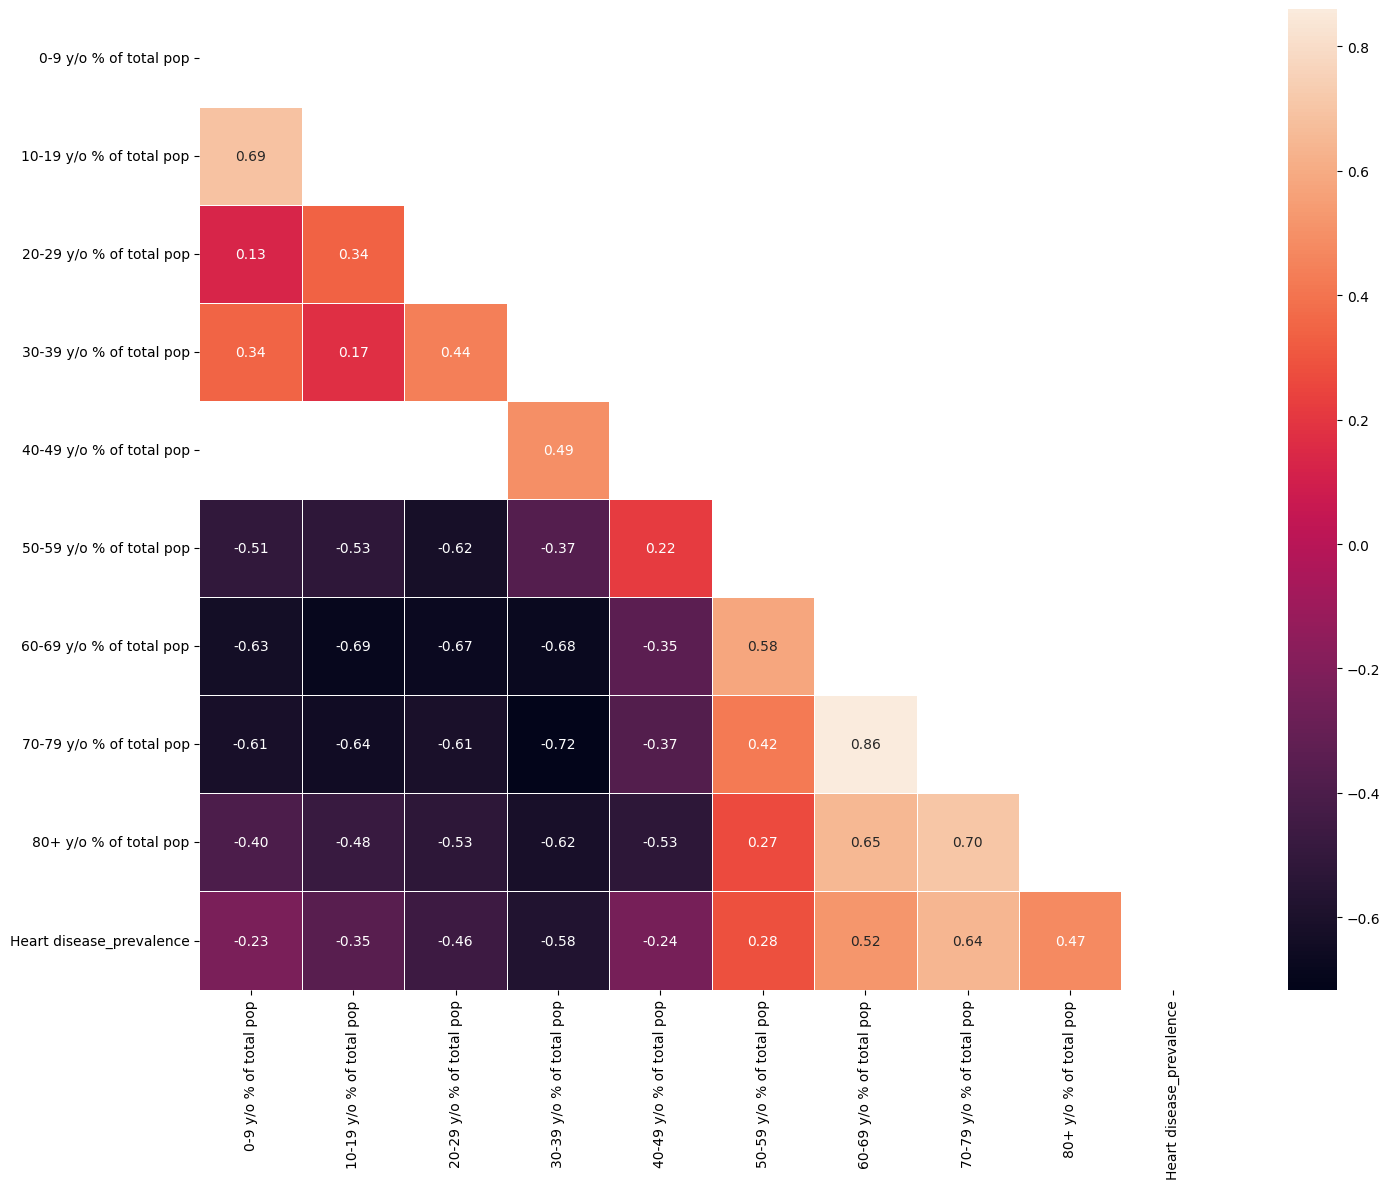

In [9]:
age_col = ["0-9 y/o % of total pop", "10-19 y/o % of total pop", "20-29 y/o % of total pop", 
       "30-39 y/o % of total pop", "40-49 y/o % of total pop",
       "50-59 y/o % of total pop", "60-69 y/o % of total pop", 
       "70-79 y/o % of total pop", "80+ y/o % of total pop", 
       "Heart disease_prevalence"]

# heatmap
corr = df[age_col].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()




In [10]:
# Combine age groups into broader categories 
df["age 0-19 pct %"] = df["0-9 y/o % of total pop"] + df["10-19 y/o % of total pop"]
df["age 20-39 pct %"] = df["20-29 y/o % of total pop"] + df["30-39 y/o % of total pop"]
df["age 40-59 pct %"] = df["40-49 y/o % of total pop"] + df["50-59 y/o % of total pop"]
df["age 60-79 pct %"] = df["60-69 y/o % of total pop"] + df["70-79 y/o % of total pop"]
df["age 80+ pct %"] = df["80+ y/o % of total pop"]



In [11]:
age_columns_to_drop = ["0-9 y/o % of total pop", "10-19 y/o % of total pop", "20-29 y/o % of total pop", "30-39 y/o % of total pop", "40-49 y/o % of total pop",
                       "50-59 y/o % of total pop", "60-69 y/o % of total pop", "70-79 y/o % of total pop", "80+ y/o % of total pop"]

df = df.drop(age_columns_to_drop, axis = 1)

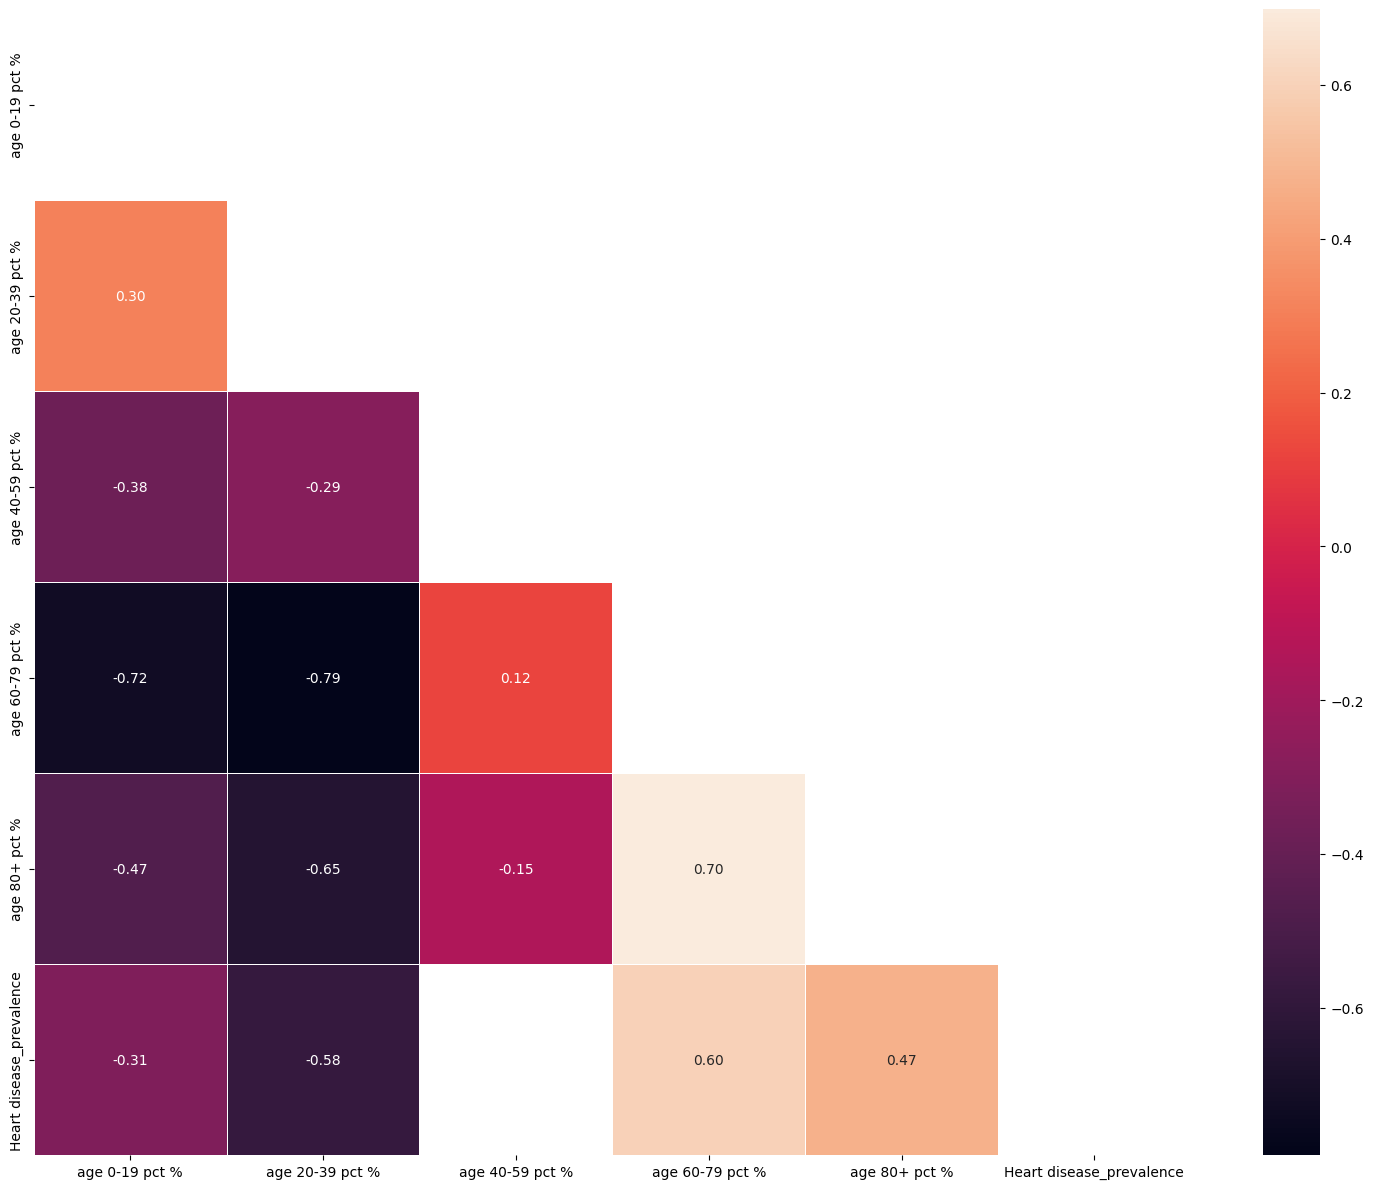

In [12]:
age_col_two = ["age 0-19 pct %", "age 20-39 pct %", "age 40-59 pct %", "age 60-79 pct %", "age 80+ pct %", "Heart disease_prevalence"]
# heatmap
corr = df[age_col_two].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
significant_corr = corr[abs(corr) > 0.1]
significant_corr
fig, axis = plt.subplots(figsize=(15, 12))
sns.heatmap(significant_corr, mask=mask, annot=True, linewidths=0.5, fmt=".2f")
plt.tight_layout()
plt.show()

**Observaciones y drops**:

* Races:

In [13]:
races = ['% White-alone', '% Black-alone', '% NA/AI-alone',
       '% Asian-alone', '% Hawaiian/PI-alone', '% Two or more races']


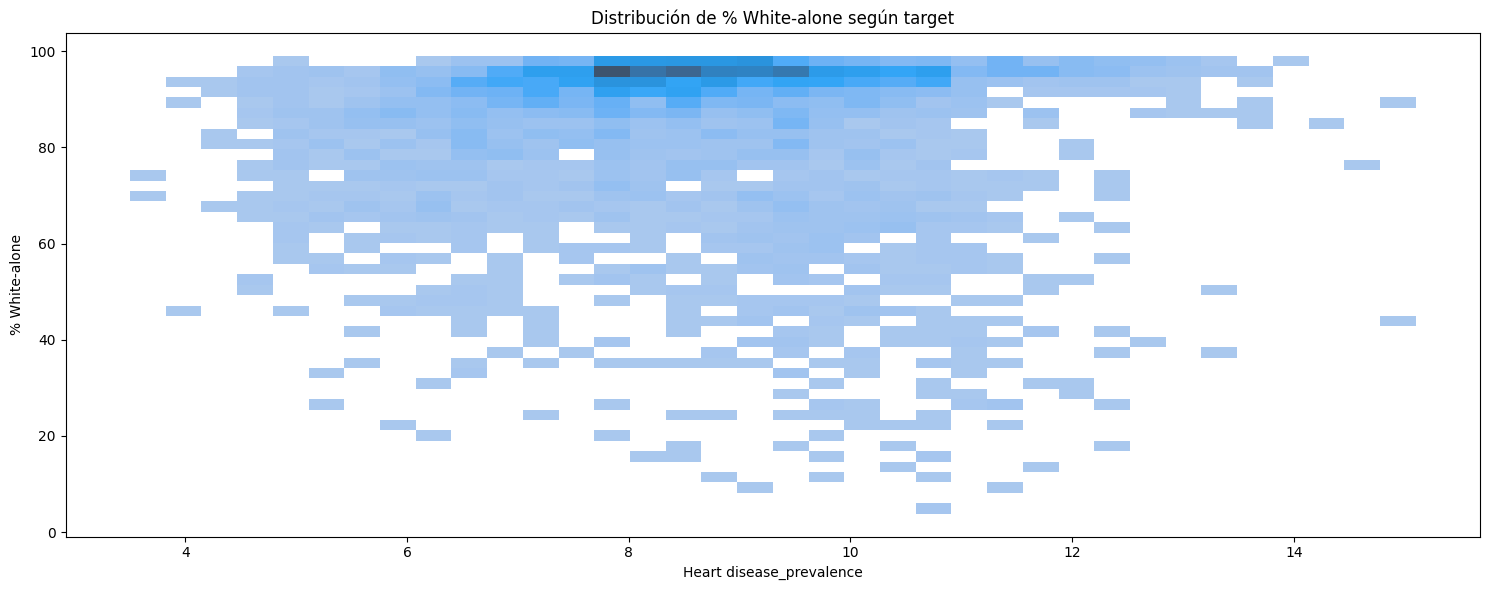

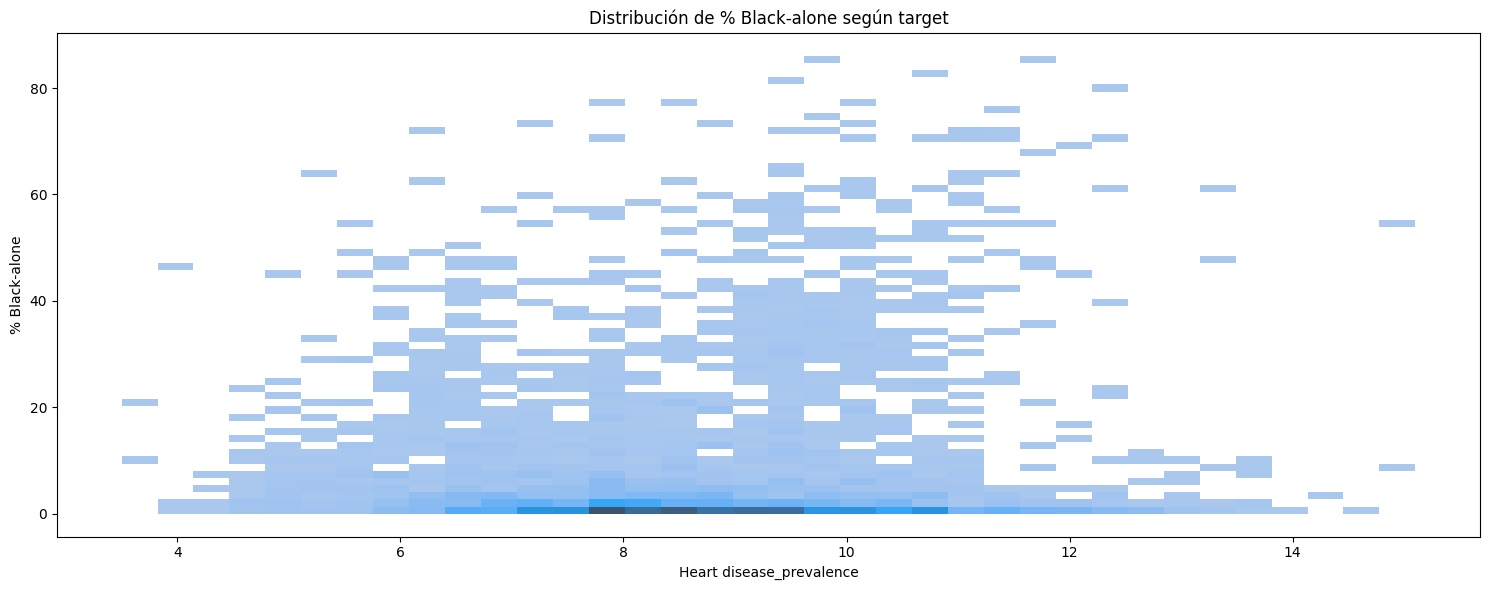

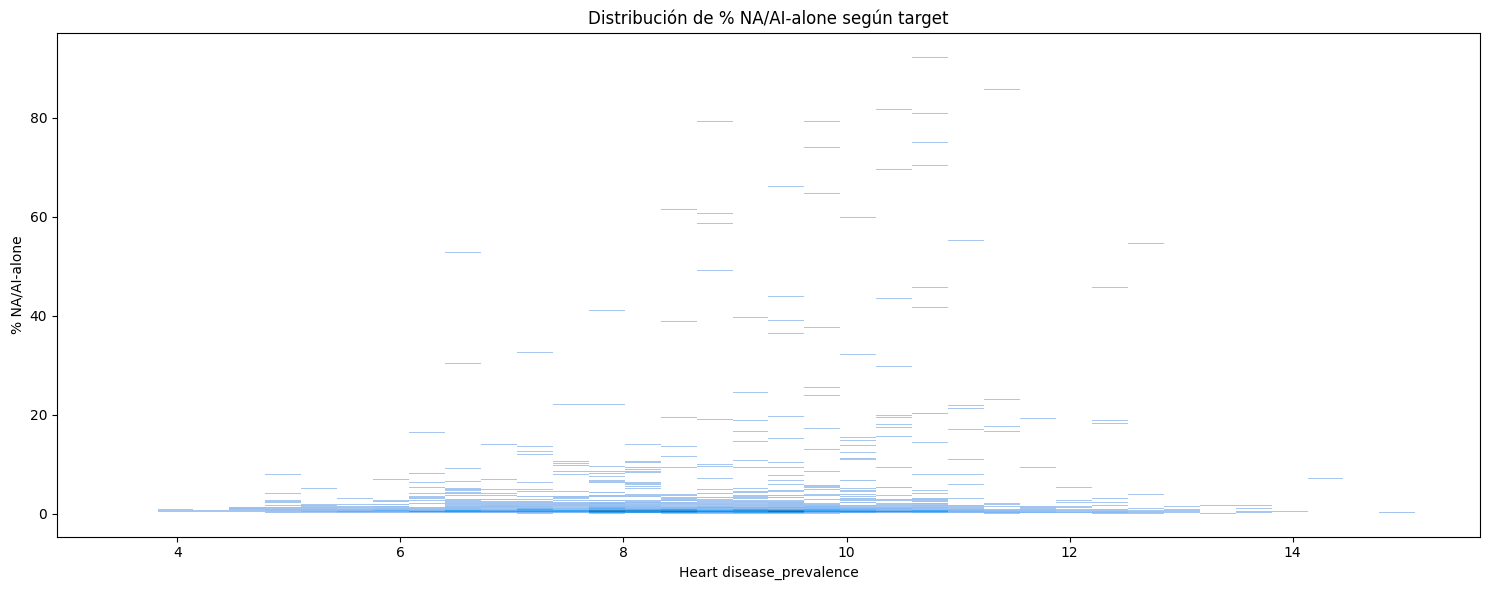

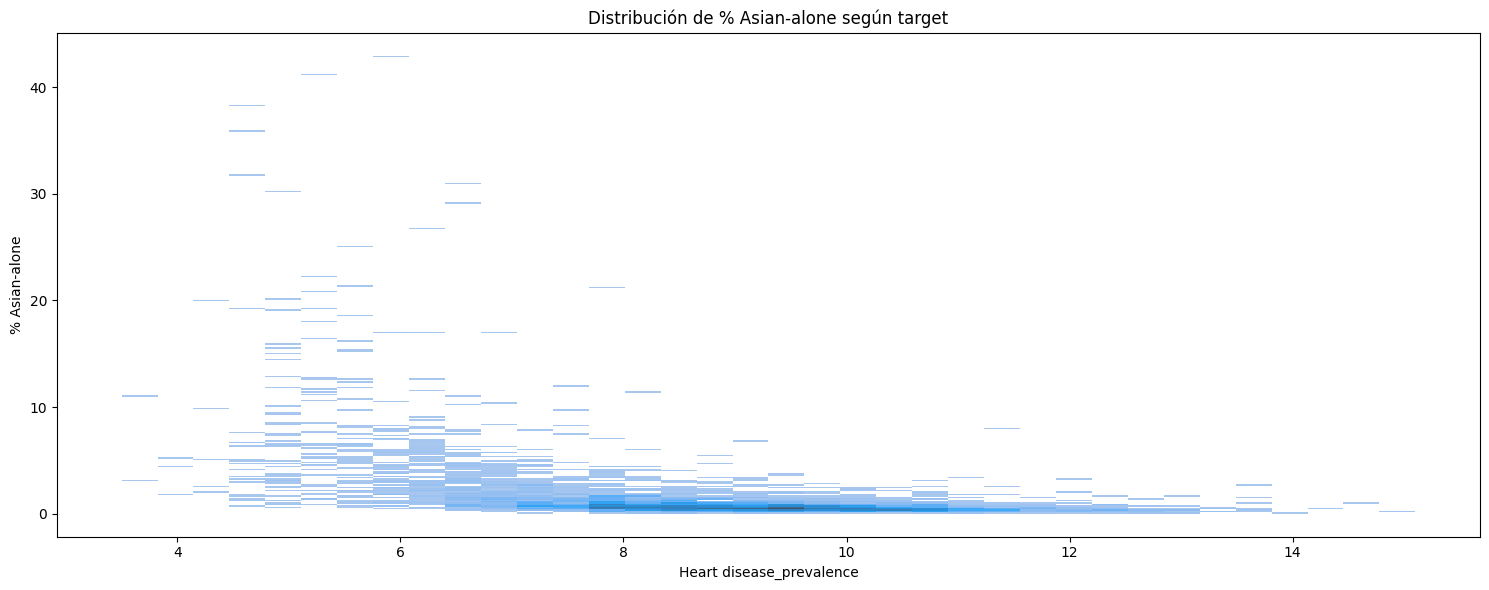

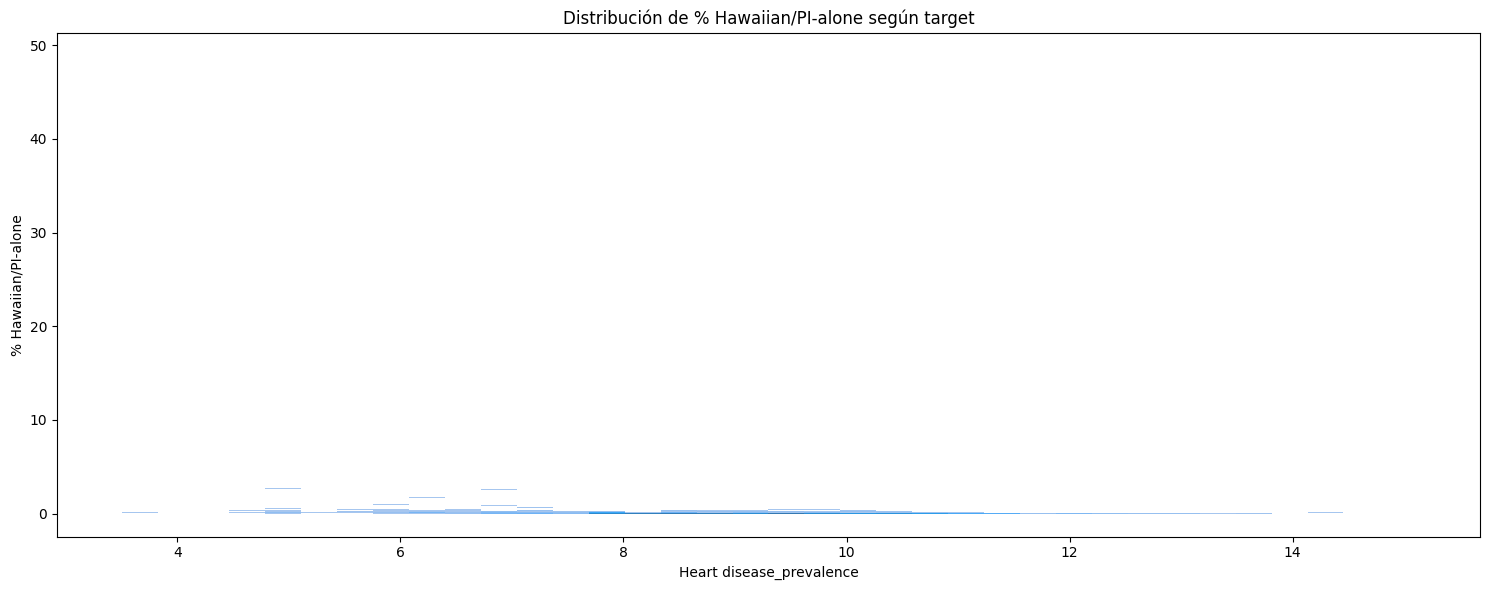

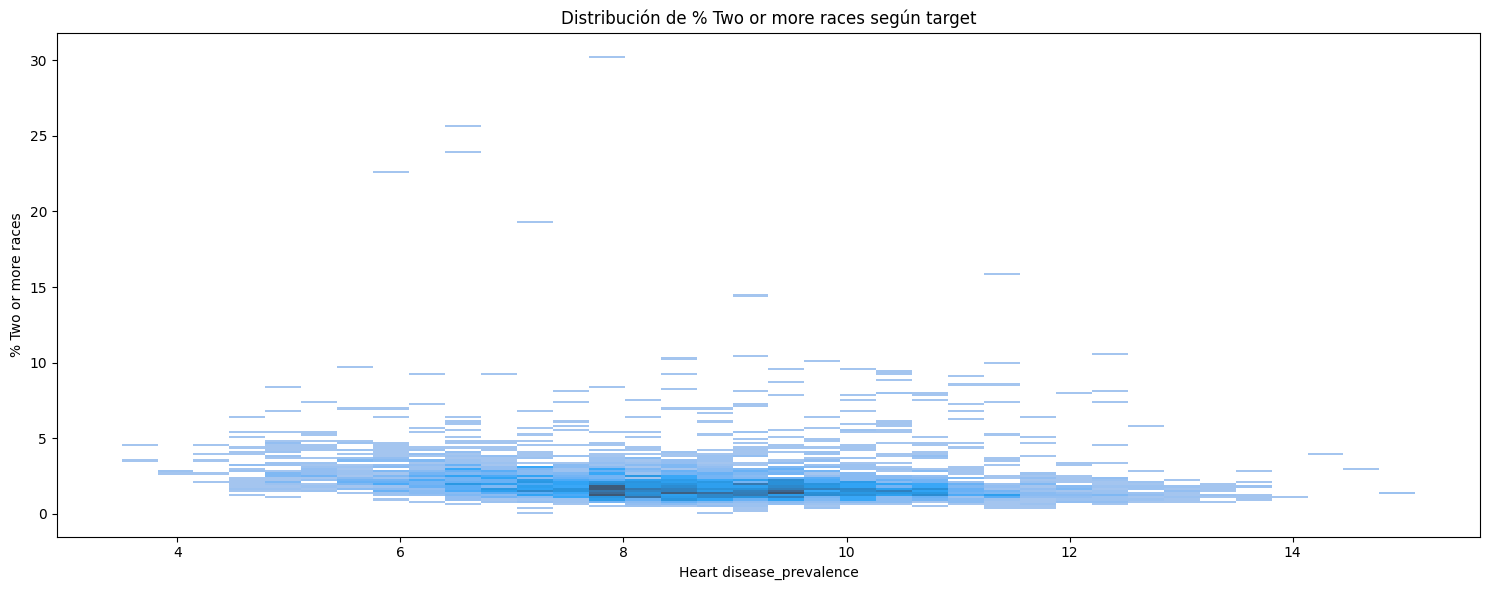

In [14]:
for columna in races:
    plt.figure(figsize=(15,6))
    sns.histplot(data=df, x="Heart disease_prevalence", y=columna)
    plt.title(f"Distribución de {columna} según target")
    plt.tight_layout()
    plt.show()

**Observaciones y drops**:
No veo necesario eliminar ninguna columna de este grupo ya que aportan información de la población y necesitamosesa infromación.

* Education

In [15]:
education = ["Less than a high school diploma 2014-18", "High school diploma only 2014-18", "Some college or associate's degree 2014-18", "Bachelor's degree or higher 2014-18"]


**Observaciones y drops**:

In [16]:
df.columns


Index(['fips', '% White-alone', '% Black-alone', '% NA/AI-alone',
       '% Asian-alone', '% Hawaiian/PI-alone', '% Two or more races',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing some college or associate's degree 2014-18',
       'Percent of adults with a bachelor's degree or higher 2014-18',
       'PCTPOVALL_2018', 'MEDHHINC_2018', 'Civilian_labor_force_2018',
       'Unemployment_rate_2018', 'Med_HH_Income_Percent_of_State_Total_2018',
       'Active Physicians per 100000 Population 2018 (AAMC)',
       'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active General Surgeons per 100000 Population 2018 (AAMC)',
       'Active Patient Care General Surgeons pe

* Location:


Me quedo con 'fips' que indica el código del condado y elimino el codigo rural urbano. Así centro la localización por estado.

In [17]:
df.drop(['Urban_rural_code'], axis=1, inplace=True) 

In [18]:

others = ['Percent of Population Aged 60+',
       'county_pop2018_18 and older', 'anycondition_prevalence',
       'anycondition_number', 'Obesity_prevalence', 'Obesity_number', 'COPD_prevalence',
       'COPD_number', 'diabetes_prevalence', 'diabetes_number',
       'CKD_prevalence', 'CKD_number', 'age 0-19 pct %',
       'age 20-39 pct %', 'age 40-59 pct %', 'age 60-79 pct %',
       'age 80+ pct %', 'Heart disease_number', 'Heart disease_prevalence']

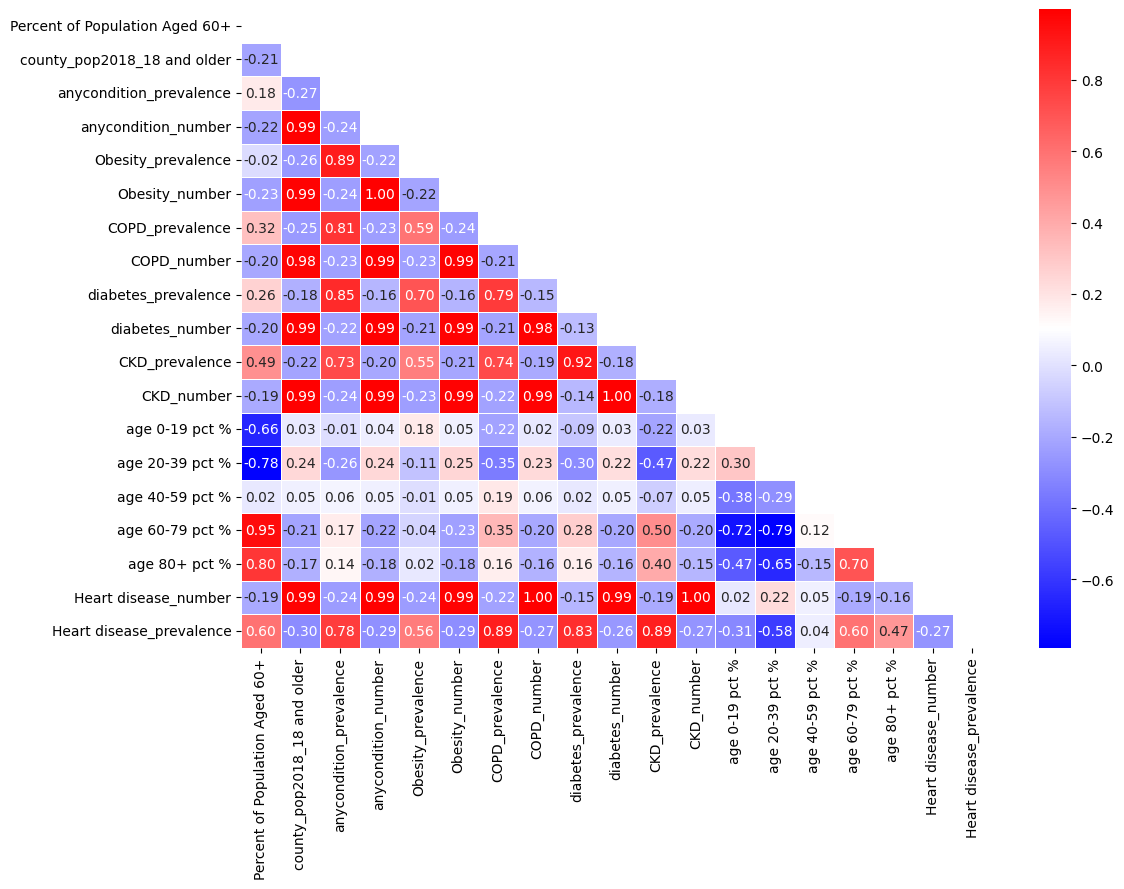

In [19]:
corr = df[others].corr

corr = df[others].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, mask=mask, linewidths=0.5, fmt=".2f", cmap='bwr')

plt.tight_layout()
plt.show()

In [20]:
df.info

<bound method DataFrame.info of        fips  % White-alone  % Black-alone  % NA/AI-alone  % Asian-alone  \
0      1001      76.725239      19.630942       0.480207       1.224798   
1      1003      87.285228       8.940382       0.772399       1.150343   
2      1005      49.069571      48.398376       0.659137       0.454162   
3      1007      76.834821      21.294643       0.437500       0.236607   
4      1009      95.878285       1.642462       0.653527       0.319848   
...     ...            ...            ...            ...            ...   
3135  56037      93.835219       1.375113       1.544680       1.010429   
3136  56039      95.190850       0.758199       0.914172       1.412417   
3137  56041      95.354451       0.827627       1.418789       0.472930   
3138  56043      94.483196       0.507292       1.813570       0.824350   
3139  56045      93.081671       0.688962       1.765466       1.937706   

      % Hawaiian/PI-alone  % Two or more races  \
0                

**Segundo heatmap de comparación en columnas finales**:

In [21]:

others_filtered = ['Percent of Population Aged 60+',
       'county_pop2018_18 and older', 'anycondition_prevalence',
       'Obesity_prevalence', 'COPD_prevalence',
       'diabetes_prevalence', 
       'CKD_prevalence', 'age 0-19 pct %',
       'age 20-39 pct %', 'age 40-59 pct %', 'age 60-79 pct %',
       'age 80+ pct %', 'Heart disease_prevalence']

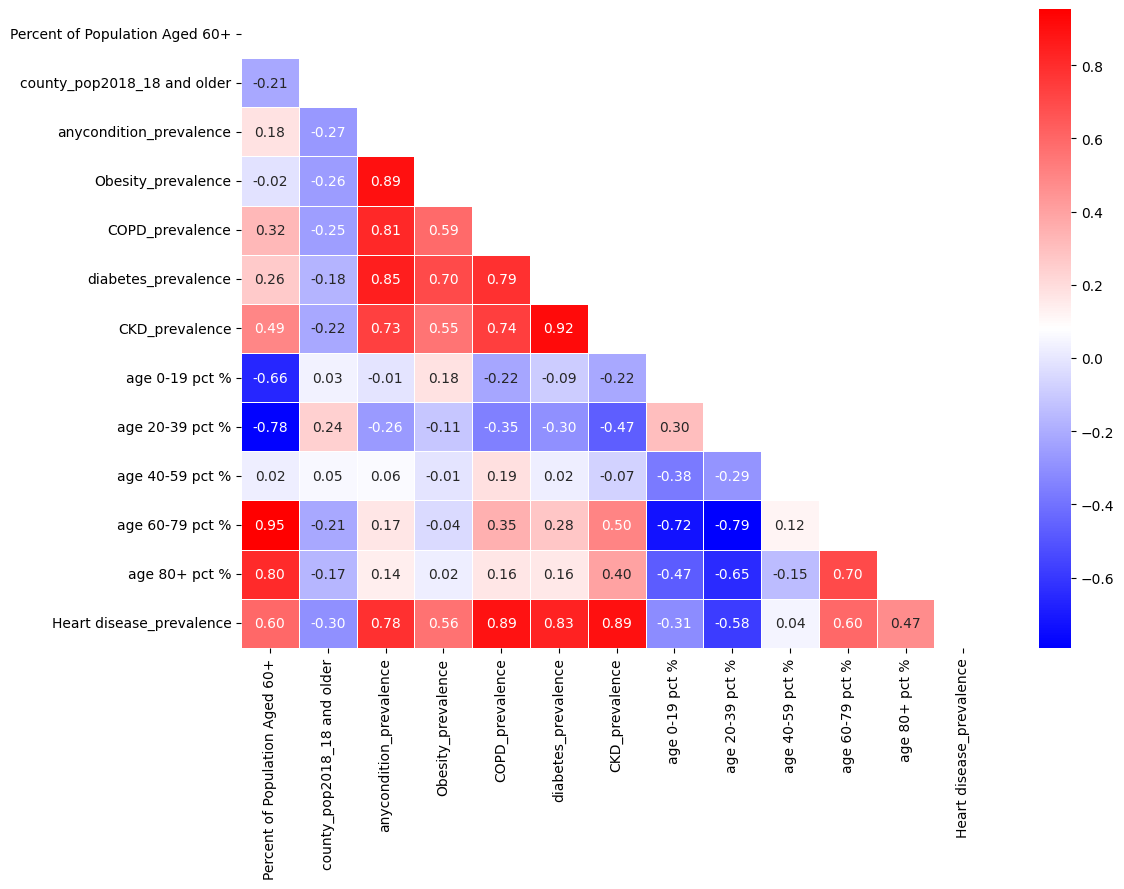

In [22]:
corr = df[others_filtered].corr

corr = df[others_filtered].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12,9))
sns.heatmap(corr, annot=True, mask=mask, linewidths=0.5, fmt=".2f", cmap='bwr')

plt.tight_layout()
plt.show()

**Drops**:

?¿?¿NO ME ESTÁ HACIENDO EL DROP

In [23]:
df = df.drop(["county_pop2018_18 and older", "anycondition_prevalence", "Percent of Population Aged 60+"], axis=1)

### **Columnas para el analisis:**

In [24]:
df.columns

Index(['fips', '% White-alone', '% Black-alone', '% NA/AI-alone',
       '% Asian-alone', '% Hawaiian/PI-alone', '% Two or more races',
       'Percent of adults with less than a high school diploma 2014-18',
       'Percent of adults with a high school diploma only 2014-18',
       'Percent of adults completing some college or associate's degree 2014-18',
       'Percent of adults with a bachelor's degree or higher 2014-18',
       'PCTPOVALL_2018', 'MEDHHINC_2018', 'Civilian_labor_force_2018',
       'Unemployment_rate_2018', 'Med_HH_Income_Percent_of_State_Total_2018',
       'Active Physicians per 100000 Population 2018 (AAMC)',
       'Total Active Patient Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active Patient Care Primary Care Physicians per 100000 Population 2018 (AAMC)',
       'Active General Surgeons per 100000 Population 2018 (AAMC)',
       'Active Patient Care General Surgeons pe

In [25]:
df.info

<bound method DataFrame.info of        fips  % White-alone  % Black-alone  % NA/AI-alone  % Asian-alone  \
0      1001      76.725239      19.630942       0.480207       1.224798   
1      1003      87.285228       8.940382       0.772399       1.150343   
2      1005      49.069571      48.398376       0.659137       0.454162   
3      1007      76.834821      21.294643       0.437500       0.236607   
4      1009      95.878285       1.642462       0.653527       0.319848   
...     ...            ...            ...            ...            ...   
3135  56037      93.835219       1.375113       1.544680       1.010429   
3136  56039      95.190850       0.758199       0.914172       1.412417   
3137  56041      95.354451       0.827627       1.418789       0.472930   
3138  56043      94.483196       0.507292       1.813570       0.824350   
3139  56045      93.081671       0.688962       1.765466       1.937706   

      % Hawaiian/PI-alone  % Two or more races  \
0                

**Observaciones y drops finales**:
> * Country_pop2018 se elimina porque ya tenemos una columna que se refiere a ese rango de edad ----> 
> * Me quedo con 46 columnas y todas las filas

##### Vars Categóricas

## PASO 5: **Split Data: tain & test**

In [26]:
X = df.drop("Heart disease_prevalence", axis=1)
y = df["Heart disease_prevalence"]

# Instancia de: from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=18)

NameError: name 'train_test_split' is not defined

## PASO 6: **Encoding**

### **Guardado de data codificada**

In [ ]:
# Utilizando Pickle (que nos permite guardar objetos de Python)
# with open('/workspaces/betaniammc-machine-learning/models/logistic-regression-label-encoder.pkl', 'wb') as file:
#     pickle.dump(label_encoder_contact, file)

### **Escalado de normalización**

In [ ]:
norm_scaler = StandardScaler()  # Instancia de: from sklearn.preprocessing import StandardScaler

NameError: name 'StandardScaler' is not defined

### **Generar modelo de entrenamiento de datos (con los datos ya escalados)**

In [ ]:
# Genera el modelo: genera una instancia de la clase LogisticRegression / Creando el modelo (vacío)
model = LogisticRegression(random_state=18)

# Entrena
model.fit(X_train_cat_le_scaled, y_train)

# ML

## PASO x: **Linear Regression Model**

APUNTES: Cómo funciona la R.Lineal / R. Logística
| Aspecto           | Regresión Logística                |
| ----------------- | ---------------------------------- |
| Tipo de problema  | Clasificación                      |
| Salida del modelo | Probabilidad entre 0 y 1           |
| Toma de decisión  | Por umbral (e.g. 0.5)              |
| Nombre confuso    | Proviene de la estadística clásica |

### **Definiciñon de variables para el modelo:**

1. VAR. DEPENDIENTE:
> * N
2. VARS INDEPENDIENTES:
> * N

### **Paso 1_Import train and test data or Split**

### **Paso 2_Iniciacion y entrenamiento del modelo**

### **Paso 3_Predicción del modelo**

In [ ]:
# pREDECIR EL CONJUNTO DE DATOS TEST
y_pred = model.predict(X_test_cat_le_scaled)
y_pred

In [ ]:
# y_pred = 
# model_accuracy -> accuracy_score(y_test,y_pred)

In [ ]:
# # Confusion matrix:

# titanic_cm = confusion_matrix(y_test, y_pred)

# # Dibujaremos esta matriz para hacerla más visual
# df_cm = pd.DataFrame(titanic_cm)

# plt.figure(figsize=(3, 3))
# sns.heatmap(df_cm, annot=True, fmt="d", cbar=False)
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.title('Confusion Matrix')

# plt.tight_layout()
# plt.show()


**Observaciones:**
> * TP (True Positive)
> * TN (True Negative)
> * FP (False Positive)
> * FN (False Negative)

### **Umbral de decisión:**

In [ ]:
# # predict() from scikit.learn sets 0.5 umbral to convert the predicted probabilities into binary labels
# # Suponiendo que 'model' es tu modelo de regresión logística ya entrenado
# y_proba = model.predict_proba(X_test)

# # Suponiendo que deseas ajustar el umbral a 0.3
# threshold = 0.3
# y_pred_threshold = np.where(y_proba[:, 1] > threshold, 1, 0)

# # Evaluar el rendimiento con el nuevo umbral
# accuracy_score(y_test, y_pred_threshold)


### **Optimicaxion de resultados:**

##### **Hiperparémetros:**

> * ``penalty``, 
> * ``C``, 
> * ``solver``, 
> * ``max_iter``, 
> * ``random_state``, 

In [ ]:
# Definición hiperparams
# GridSearchCV()
# Metodo .fit(X_train,y_train) -> determinates penalty¿?
# grid -> accurary - model accuracy comparation
# model_random_search -> nueva hiperparametrizacion para entrenar el modelo